# Stock Direction v4: Dynamic Neutral + Two-Stage Classifier

This notebook is a next step after v1-v3.

Main changes:
- dynamic `bez_zmian` threshold based on rolling volatility,
- two-stage model:
  1. `ruch` vs `bez_ruchu`,
  2. `spadek` vs `wzrost` only for predicted movement,
- walk-forward validation on train period,
- final test on last 2 months.

Source files are not modified.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
TEST_MONTHS = 2
CV_FOLDS = 3
CV_VAL_SIZE = 40
CV_MIN_TRAIN = 260

CLASS_ORDER = ["spadek", "bez_zmian", "wzrost"]
CODE_TO_CLASS = {0: "spadek", 1: "bez_zmian", 2: "wzrost"}
CLASS_CODE_ORDER = [0, 1, 2]

VOL_K_CANDIDATES = [0.8, 1.0, 1.2]
NEUTRAL_FLOOR_CANDIDATES = [0.002, 0.003]
LAG_SCHEMES = {
    "short": [1, 2, 3, 5, 10],
    "extended": [1, 2, 3, 5, 10, 15],
}

TOP_K_SEARCH = [40, 80, 120]
MOVE_THR_SEARCH = [0.45, 0.50, 0.55]
DIR_MARGIN_SEARCH = [0.00, 0.05, 0.10]
C_PAIRS_SEARCH = [(1.0, 1.0), (2.0, 1.0)]  # (C_stage1, C_stage2)


In [2]:
def make_folds(n, n_folds=3, val_size=40, min_train=260):
    folds = []
    for i in range(n_folds):
        val_end = n - val_size * (n_folds - 1 - i)
        val_start = val_end - val_size
        if val_start < min_train:
            continue
        folds.append((np.arange(0, val_start), np.arange(val_start, val_end)))
    return folds


def add_lags(frame, feature_cols, lags):
    parts = [frame]
    for lag in lags:
        shifted = frame[feature_cols].shift(lag).rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        parts.append(shifted)
    return pd.concat(parts, axis=1)


def select_top_k_by_mi(X_train, y_train, k):
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train, random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][: min(k, len(mi))]
    return [X_train.columns[i] for i in idx]


def build_dynamic_dataset(base_df, base_features, vol_k, neutral_floor, lags):
    df = base_df.copy()
    if "stock_return_1d" in df.columns:
        ret_for_vol = df["stock_return_1d"].copy()
    else:
        ret_for_vol = df["stock_price"].pct_change(1)

    vol20 = ret_for_vol.rolling(20).std().shift(1)
    vol20 = vol20.fillna(vol20.median())
    dynamic_band = (vol_k * vol20).clip(lower=neutral_floor, upper=0.03)

    df["future_return_1d"] = df["stock_price"].shift(-1) / df["stock_price"] - 1
    df["dynamic_neutral_band"] = dynamic_band

    y_code = np.full(len(df), -1, dtype=np.int64)
    y_code[df["future_return_1d"] < -df["dynamic_neutral_band"]] = 0
    y_code[df["future_return_1d"].abs() <= df["dynamic_neutral_band"]] = 1
    y_code[df["future_return_1d"] > df["dynamic_neutral_band"]] = 2
    df["y_code"] = y_code
    df["y"] = pd.Series(y_code).map(CODE_TO_CLASS)

    core = df[["date", "future_return_1d", "dynamic_neutral_band", "y", "y_code"] + base_features].copy()
    lagged = add_lags(core, base_features, lags)
    lagged = lagged[lagged["y_code"] >= 0].copy().reset_index(drop=True)
    model_features = [c for c in lagged.columns if c not in ["date", "future_return_1d", "dynamic_neutral_band", "y", "y_code"]]
    return df, lagged, model_features


def fit_two_stage(train_X, train_y3, selected_cols, c1=1.0, c2=1.0):
    y_move = (train_y3 != 1).astype(int)
    stage1 = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("clf", LogisticRegression(C=c1, class_weight="balanced", max_iter=3000, solver="liblinear", random_state=RANDOM_STATE)),
        ]
    )
    stage1.fit(train_X[selected_cols], y_move)

    move_mask = train_y3 != 1
    y_dir = (train_y3[move_mask] == 2).astype(int)
    stage2 = None
    constant_up_prob = 0.5
    if len(np.unique(y_dir)) >= 2:
        stage2 = Pipeline(
            steps=[
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler()),
                ("clf", LogisticRegression(C=c2, class_weight="balanced", max_iter=3000, solver="liblinear", random_state=RANDOM_STATE + 1)),
            ]
        )
        stage2.fit(train_X.loc[move_mask, selected_cols], y_dir)
    else:
        constant_up_prob = float(np.mean(y_dir)) if len(y_dir) > 0 else 0.5

    return stage1, stage2, constant_up_prob


def predict_two_stage(stage1, stage2, const_up_prob, X, selected_cols, move_thr=0.5, dir_margin=0.0):
    p_move = stage1.predict_proba(X[selected_cols])[:, 1]
    if stage2 is None:
        p_up = np.full(len(X), const_up_prob)
    else:
        p_up = stage2.predict_proba(X[selected_cols])[:, 1]

    pred = np.full(len(X), 1, dtype=np.int64)
    move_mask = p_move >= move_thr
    dir_conf = np.abs(p_up - 0.5)
    confident = dir_conf >= dir_margin
    down_mask = move_mask & confident & (p_up < 0.5)
    up_mask = move_mask & confident & (p_up >= 0.5)
    pred[down_mask] = 0
    pred[up_mask] = 2
    return pred, p_move, p_up


def eval_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "neutral_recall": recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0],
    }


In [3]:
# Load base dataset from previous notebooks (v2 preferred, v1 fallback)
data_root = next((p for p in [Path("../data/equity_data"), Path("data/equity_data")] if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Could not find data/equity_data")
model_dir = data_root / "model_data"
model_dir.mkdir(parents=True, exist_ok=True)

base_candidates = [
    model_dir / "stock_direction_dataset_v2_base_best.csv",
    model_dir / "stock_direction_dataset_base.csv",
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError("Run notebook v1 or v2 first to create base dataset")

base_df = pd.read_csv(base_path)
base_df["date"] = pd.to_datetime(base_df["date"], errors="coerce")
base_df = base_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

for c in base_df.columns:
    if c != "date":
        base_df[c] = pd.to_numeric(base_df[c], errors="coerce")

exclude = {"date", "y", "y_code", "future_return_1d", "dynamic_neutral_band"}
base_features = [c for c in base_df.columns if c not in exclude]

print(f"Base source: {base_path}")
print(f"Rows: {len(base_df):,} | base features: {len(base_features)}")
print(f"Date range: {base_df['date'].min().date()} -> {base_df['date'].max().date()}")


Base source: ..\data\equity_data\model_data\stock_direction_dataset_v2_base_best.csv
Rows: 751 | base features: 44
Date range: 2023-01-03 -> 2025-12-30


In [4]:
# Stage A: choose dynamic label setup (vol_k + neutral_floor + lag scheme)
stage_a_rows = []
prepared = {}

for vol_k in VOL_K_CANDIDATES:
    for floor in NEUTRAL_FLOOR_CANDIDATES:
        for lag_name, lags in LAG_SCHEMES.items():
            _, lagged_df, model_features = build_dynamic_dataset(
                base_df=base_df,
                base_features=base_features,
                vol_k=vol_k,
                neutral_floor=floor,
                lags=lags,
            )

            test_start = (lagged_df["date"].max() - pd.DateOffset(months=TEST_MONTHS)).normalize()
            train_df = lagged_df[lagged_df["date"] < test_start].copy()
            test_df = lagged_df[lagged_df["date"] >= test_start].copy()
            if train_df.empty or test_df.empty:
                continue

            folds = make_folds(len(train_df), CV_FOLDS, CV_VAL_SIZE, CV_MIN_TRAIN)
            if not folds:
                continue

            fold_metrics = []
            for tr_idx, va_idx in folds:
                tr = train_df.iloc[tr_idx]
                va = train_df.iloc[va_idx]

                top_cols = select_top_k_by_mi(tr[model_features], tr["y_code"].to_numpy(), 80)
                stage1, stage2, const_up = fit_two_stage(tr, tr["y_code"].to_numpy(), top_cols, c1=1.0, c2=1.0)
                va_pred, _, _ = predict_two_stage(stage1, stage2, const_up, va, top_cols, move_thr=0.5, dir_margin=0.0)
                fold_metrics.append(eval_metrics(va["y_code"].to_numpy(), va_pred))

            macro_f1 = float(np.mean([m["macro_f1"] for m in fold_metrics]))
            bal_acc = float(np.mean([m["balanced_accuracy"] for m in fold_metrics]))
            neutral_recall = float(np.mean([m["neutral_recall"] for m in fold_metrics]))
            score = 0.6 * macro_f1 + 0.2 * bal_acc + 0.2 * neutral_recall

            stage_a_rows.append(
                {
                    "vol_k": vol_k,
                    "neutral_floor": floor,
                    "lag_name": lag_name,
                    "lags": str(lags),
                    "n_features": len(model_features),
                    "cv_macro_f1": macro_f1,
                    "cv_bal_acc": bal_acc,
                    "cv_neutral_recall": neutral_recall,
                    "cv_score": score,
                    "train_rows": len(train_df),
                    "test_rows": len(test_df),
                    "test_start": str(test_start.date()),
                }
            )

            prepared[(vol_k, floor, lag_name)] = {
                "lagged_df": lagged_df,
                "model_features": model_features,
                "train_df": train_df,
                "test_df": test_df,
                "test_start": test_start,
                "lags": lags,
            }

stage_a_df = pd.DataFrame(stage_a_rows).sort_values("cv_score", ascending=False).reset_index(drop=True)
display(stage_a_df)
best_a = stage_a_df.iloc[0].to_dict()
print("Best Stage A:", best_a)


,vol_k,neutral_floor,lag_name,lags,n_features,cv_macro_f1,cv_bal_acc,cv_neutral_recall,cv_score,train_rows,test_rows,test_start
0,1.2,0.002,short,"[1, 2, 3, 5, 10]",264,0.354381,0.400980,0.468019,0.386428,708,42,2025-10-29
1,1.2,0.003,short,"[1, 2, 3, 5, 10]",264,0.354381,0.400980,0.468019,0.386428,708,42,2025-10-29
2,1.0,0.003,extended,"[1, 2, 3, 5, 10, 15]",308,0.291394,0.295733,0.461009,0.326185,708,42,2025-10-29
3,1.0,0.002,extended,"[1, 2, 3, 5, 10, 15]",308,0.291394,0.295733,0.461009,0.326185,708,42,2025-10-29
4,1.0,0.003,short,"[1, 2, 3, 5, 10]",264,0.291960,0.330424,0.424208,0.326102,708,42,2025-10-29
5,1.0,0.002,short,"[1, 2, 3, 5, 10]",264,0.291960,0.330424,0.424208,0.326102,708,42,2025-10-29
6,0.8,0.003,short,"[1, 2, 3, 5, 10]",264,0.242492,0.238856,0.361542,0.265575,708,42,2025-10-29
7,0.8,0.002,short,"[1, 2, 3, 5, 10]",264,0.242492,0.238856,0.361542,0.265575,708,42,2025-10-29
8,0.8,0.003,extended,"[1, 2, 3, 5, 10, 15]",308,0.228638,0.223091,0.362923,0.254385,708,42,2025-10-29
9,0.8,0.002,extended,"[1, 2, 3, 5, 10, 15]",308,0.228638,0.223091,0.362923,0.254385,708,42,2025-10-29


Best Stage A: {'vol_k': 1.2, 'neutral_floor': 0.002, 'lag_name': 'short', 'lags': '[1, 2, 3, 5, 10]', 'n_features': 264, 'cv_macro_f1': 0.3543806565268794, 'cv_bal_acc': 0.4009799861973775, 'cv_neutral_recall': 0.46801932367149757, 'cv_score': 0.3864282558899026, 'train_rows': 708, 'test_rows': 42, 'test_start': '2025-10-29'}


In [5]:
# Stage B: tune two-stage decision settings on selected dynamic dataset
key = (float(best_a["vol_k"]), float(best_a["neutral_floor"]), str(best_a["lag_name"]))
selected = prepared[key]
train_df = selected["train_df"].copy()
test_df = selected["test_df"].copy()
model_features = selected["model_features"]

folds = make_folds(len(train_df), CV_FOLDS, CV_VAL_SIZE, CV_MIN_TRAIN)
stage_b_rows = []

for top_k in TOP_K_SEARCH:
    for (c1, c2) in C_PAIRS_SEARCH:
        for move_thr in MOVE_THR_SEARCH:
            for dir_margin in DIR_MARGIN_SEARCH:
                fold_metrics = []
                for tr_idx, va_idx in folds:
                    tr = train_df.iloc[tr_idx]
                    va = train_df.iloc[va_idx]
                    cols = select_top_k_by_mi(tr[model_features], tr["y_code"].to_numpy(), top_k)

                    stage1, stage2, const_up = fit_two_stage(tr, tr["y_code"].to_numpy(), cols, c1=c1, c2=c2)
                    va_pred, _, _ = predict_two_stage(
                        stage1,
                        stage2,
                        const_up,
                        va,
                        cols,
                        move_thr=move_thr,
                        dir_margin=dir_margin,
                    )
                    fold_metrics.append(eval_metrics(va["y_code"].to_numpy(), va_pred))

                macro_f1 = float(np.mean([m["macro_f1"] for m in fold_metrics]))
                bal_acc = float(np.mean([m["balanced_accuracy"] for m in fold_metrics]))
                neutral_recall = float(np.mean([m["neutral_recall"] for m in fold_metrics]))
                score = 0.6 * macro_f1 + 0.2 * bal_acc + 0.2 * neutral_recall

                stage_b_rows.append(
                    {
                        "top_k": top_k,
                        "c1": c1,
                        "c2": c2,
                        "move_thr": move_thr,
                        "dir_margin": dir_margin,
                        "cv_macro_f1": macro_f1,
                        "cv_bal_acc": bal_acc,
                        "cv_neutral_recall": neutral_recall,
                        "cv_score": score,
                    }
                )

stage_b_df = pd.DataFrame(stage_b_rows).sort_values("cv_score", ascending=False).reset_index(drop=True)
display(stage_b_df)
best_b = stage_b_df.iloc[0].to_dict()
print("Best Stage B:", best_b)


,top_k,c1,c2,move_thr,dir_margin,cv_macro_f1,cv_bal_acc,cv_neutral_recall,cv_score
0,40,2.0,1.0,0.55,0.10,0.356366,0.376802,0.768502,0.442881
1,40,1.0,1.0,0.55,0.10,0.351778,0.371971,0.754010,0.436263
2,40,2.0,1.0,0.55,0.05,0.367806,0.369680,0.699517,0.434523
3,40,2.0,1.0,0.55,0.00,0.370226,0.368939,0.663961,0.428716
4,40,1.0,1.0,0.55,0.05,0.363236,0.364849,0.685024,0.427916
5,40,1.0,1.0,0.55,0.00,0.365656,0.364109,0.649469,0.422109
6,40,2.0,1.0,0.50,0.10,0.355351,0.421182,0.612754,0.419998
7,80,1.0,1.0,0.55,0.05,0.372324,0.409547,0.560386,0.417381
8,80,2.0,1.0,0.55,0.05,0.372715,0.409160,0.559227,0.417307
9,40,1.0,1.0,0.50,0.10,0.353373,0.417479,0.601643,0.415848


Best Stage B: {'top_k': 40.0, 'c1': 2.0, 'c2': 1.0, 'move_thr': 0.55, 'dir_margin': 0.1, 'cv_macro_f1': 0.35636642723488704, 'cv_bal_acc': 0.3768023924545663, 'cv_neutral_recall': 0.7685024154589373, 'cv_score': 0.44288081792363293}


,model,split,accuracy,balanced_accuracy,macro_f1,neutral_recall
0,Dummy(most_frequent),test,0.6190,0.3333,0.2549,1.0000
1,TwoStage_v4,train,0.6257,0.4425,0.4567,0.8562
2,TwoStage_v4,test,0.5714,0.3654,0.3333,0.8462


Best dynamic setup: vol_k=1.2, floor=0.002, lags=[1, 2, 3, 5, 10]
Best two-stage setup: top_k=40, c1=2.0, c2=1.0, move_thr=0.55, dir_margin=0.1
Classification report (test):
              precision    recall  f1-score   support

      spadek       0.29      0.25      0.27         8
   bez_zmian       0.65      0.85      0.73        26
      wzrost       0.00      0.00      0.00         8

    accuracy                           0.57        42
   macro avg       0.31      0.37      0.33        42
weighted avg       0.45      0.57      0.50        42



,pred: spadek,pred: bez_zmian,pred: wzrost
real: spadek,2,5,1
real: bez_zmian,4,22,0
real: wzrost,1,7,0


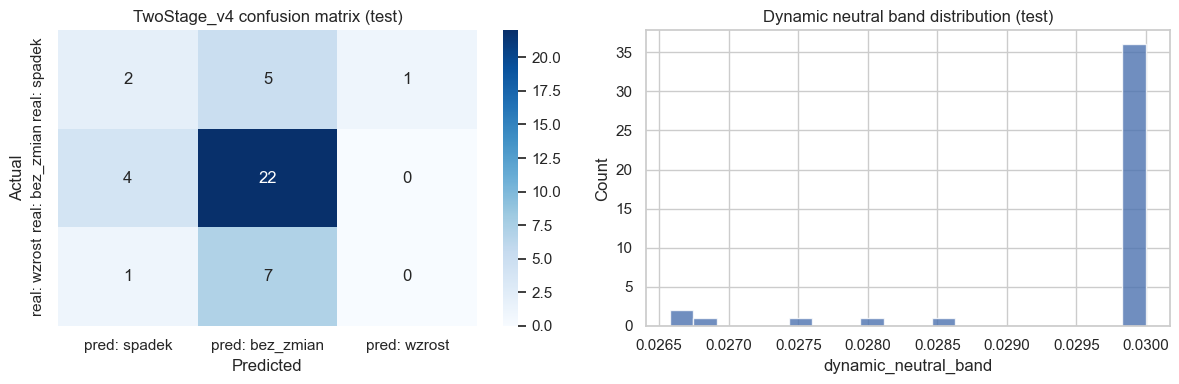

..\data\equity_data\model_data\stock_direction_v4_stage_a_results.csv
..\data\equity_data\model_data\stock_direction_v4_stage_b_results.csv
..\data\equity_data\model_data\stock_direction_v4_metrics.csv
..\data\equity_data\model_data\stock_direction_v4_test_predictions.csv
..\data\equity_data\model_data\stock_direction_v4_selected_features.csv
..\data\equity_data\model_data\stock_direction_dataset_v4_lagged_best.csv


In [6]:
# Final fit on full train and evaluate on holdout test
top_k = int(best_b["top_k"])
c1 = float(best_b["c1"])
c2 = float(best_b["c2"])
move_thr = float(best_b["move_thr"])
dir_margin = float(best_b["dir_margin"])

selected_cols = select_top_k_by_mi(train_df[model_features], train_df["y_code"].to_numpy(), top_k)
stage1, stage2, const_up = fit_two_stage(train_df, train_df["y_code"].to_numpy(), selected_cols, c1=c1, c2=c2)

pred_train, p_move_train, p_up_train = predict_two_stage(stage1, stage2, const_up, train_df, selected_cols, move_thr=move_thr, dir_margin=dir_margin)
pred_test, p_move_test, p_up_test = predict_two_stage(stage1, stage2, const_up, test_df, selected_cols, move_thr=move_thr, dir_margin=dir_margin)

y_train = train_df["y_code"].to_numpy()
y_test = test_df["y_code"].to_numpy()

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train_df[selected_cols].fillna(0), y_train)
pred_dummy_test = dummy.predict(test_df[selected_cols].fillna(0))

metrics_df = pd.DataFrame(
    [
        {
            "model": "Dummy(most_frequent)",
            "split": "test",
            **eval_metrics(y_test, pred_dummy_test),
        },
        {
            "model": "TwoStage_v4",
            "split": "train",
            **eval_metrics(y_train, pred_train),
        },
        {
            "model": "TwoStage_v4",
            "split": "test",
            **eval_metrics(y_test, pred_test),
        },
    ]
)
display(metrics_df.round(4))

print(f"Best dynamic setup: vol_k={best_a['vol_k']}, floor={best_a['neutral_floor']}, lags={best_a['lags']}")
print(f"Best two-stage setup: top_k={top_k}, c1={c1}, c2={c2}, move_thr={move_thr}, dir_margin={dir_margin}")
print("Classification report (test):")
print(classification_report(y_test, pred_test, labels=CLASS_CODE_ORDER, target_names=CLASS_ORDER, zero_division=0))

cm = confusion_matrix(y_test, pred_test, labels=CLASS_CODE_ORDER)
cm_df = pd.DataFrame(cm, index=[f"real: {c}" for c in CLASS_ORDER], columns=[f"pred: {c}" for c in CLASS_ORDER])
display(cm_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("TwoStage_v4 confusion matrix (test)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[1].hist(test_df["dynamic_neutral_band"], bins=20, alpha=0.8)
axes[1].set_title("Dynamic neutral band distribution (test)")
axes[1].set_xlabel("dynamic_neutral_band")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

preds_df = pd.DataFrame(
    {
        "date": test_df["date"].values,
        "y_true": y_test,
        "y_pred": pred_test,
        "p_move": p_move_test,
        "p_up": p_up_test,
        "dynamic_neutral_band": test_df["dynamic_neutral_band"].values,
        "future_return_1d": test_df["future_return_1d"].values,
    }
)

stage_a_path = model_dir / "stock_direction_v4_stage_a_results.csv"
stage_b_path = model_dir / "stock_direction_v4_stage_b_results.csv"
metrics_path = model_dir / "stock_direction_v4_metrics.csv"
preds_path = model_dir / "stock_direction_v4_test_predictions.csv"
features_path = model_dir / "stock_direction_v4_selected_features.csv"
lagged_path = model_dir / "stock_direction_dataset_v4_lagged_best.csv"

stage_a_df.to_csv(stage_a_path, index=False)
stage_b_df.to_csv(stage_b_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
pd.DataFrame({"feature": selected_cols}).to_csv(features_path, index=False)
selected["lagged_df"].to_csv(lagged_path, index=False)

print(stage_a_path)
print(stage_b_path)
print(metrics_path)
print(preds_path)
print(features_path)
print(lagged_path)
